In [1]:
from run_simulation import run_multiple_simulations, print_statistics
import numpy as np

num_permits = 6410
n_runs = 100
base_seed = 42

scenario = {
    "name": "standard_custom_non_like",
    "sequential": "standard",
    "pct_pre_approved": 0.018,
    "pct_custom": 0.91,
    "pct_self_cert": 0.081,
    "pct_like_for_like": 0.803,
}

print(f"Running {n_runs} simulations ({num_permits} permits each, collecting permits for analysis and plots)...")
results = run_multiple_simulations(
    n_runs=n_runs,
    num_permits=num_permits,
    inter_arrival_time=0,
    base_seed=base_seed,
    scenario_params_list=[scenario],
    collect_permits=True,
)

results_runs = results

run_mean_total = np.array(
    [r["stats"]["average_total_time"]["mean"] for r in results_runs],
    dtype=float,
)
run_median_total = np.array(
    [r["stats"]["average_total_time"]["median"] for r in results_runs],
    dtype=float,
)

print("\nAcross 100 runs — per-run mean total time (disaster → construction):")
print(f"  Mean:    {run_mean_total.mean():.2f} days")
print(f"  Median:  {np.median(run_mean_total):.2f} days")
print(f"  Std dev: {run_mean_total.std(ddof=1):.2f} days")
print(f"  Min:     {run_mean_total.min():.2f} days")
print(f"  Max:     {run_mean_total.max():.2f} days")

print("\nAcross 100 runs — per-run median total time:")
print(f"  Mean:    {run_median_total.mean():.2f} days")
print(f"  Median:  {np.median(run_median_total):.2f} days")
print(f"  Std dev: {run_median_total.std(ddof=1):.2f} days")
print(f"  Min:     {run_median_total.min():.2f} days")
print(f"  Max:     {run_median_total.max():.2f} days")

# All permits from all 100 runs (for aggregate visualizations below)
all_permits = [p for r in results for p in r["permits"]]

print(f"\nCollected {len(all_permits)} permit records ({n_runs} runs × {num_permits} permits).")

print_statistics(results[0]["stats"])


Running 100 simulations (6410 permits each, collecting permits for analysis and plots)...

Across 100 runs — per-run mean total time (disaster → construction):
  Mean:    756.57 days
  Median:  756.54 days
  Std dev: 7.55 days
  Min:     737.71 days
  Max:     779.41 days

Across 100 runs — per-run median total time:
  Mean:    564.68 days
  Median:  563.85 days
  Std dev: 5.69 days
  Min:     550.73 days
  Max:     579.13 days

Collected 638870 permit records (100 runs × 6410 permits).

SIMULATION STATISTICS

Total Completed Permits: 6387
Total In Progress: 23

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   : 4642 (72.68%)
  CUSTOM_NON_LIKE               : 1128 (17.66%)
  PRE_APPROVED_LIKE             :   80 ( 1.25%)
  PRE_APPROVED_NON_LIKE         :   19 ( 0.30%)
  SELF_CERT_LIKE                :  425 ( 6.65%)
  SELF_C

In [2]:
# County review vs applicant time across runs
# Uses `results_runs` from the first cell.

county_means = []
county_medians = []
applicant_means = []
applicant_medians = []
county_stds = []
applicant_stds = []

definitions = []
for r in results_runs:
    cv = r["stats"].get("county_review_vs_applicant", {})
    if not cv:
        continue
    county_means.append(cv.get("county_review_mean", np.nan))
    county_medians.append(cv.get("county_review_median", np.nan))
    applicant_means.append(cv.get("applicant_mean", np.nan))
    applicant_medians.append(cv.get("applicant_median", np.nan))
    county_stds.append(cv.get("county_review_std", np.nan))
    applicant_stds.append(cv.get("applicant_std", np.nan))
    if cv.get("definition"):
        definitions.append(cv["definition"])

if not county_means:
    raise RuntimeError("No county_review_vs_applicant metrics found. Run the simulation cell first.")

county_means = np.array(county_means, dtype=float)
county_medians = np.array(county_medians, dtype=float)
applicant_means = np.array(applicant_means, dtype=float)
applicant_medians = np.array(applicant_medians, dtype=float)
county_stds = np.array(county_stds, dtype=float)
applicant_stds = np.array(applicant_stds, dtype=float)

print("Across runs — county review time (days per permit):")
print(f"  Mean of run means:   {county_means.mean():.2f}")
print(f"  Mean of run medians: {county_medians.mean():.2f}")
print(f"  Mean of run std dev: {county_stds.mean():.2f}")

print("\nAcross runs — applicant time (days per permit):")
print(f"  Mean of run means:   {applicant_means.mean():.2f}")
print(f"  Mean of run medians: {applicant_medians.mean():.2f}")
print(f"  Mean of run std dev: {applicant_stds.mean():.2f}")

if definitions:
    print("\nDefinition:")
    print(definitions[0])

Across runs — county review time (days per permit):
  Mean of run means:   38.69
  Mean of run medians: 19.79
  Mean of run std dev: 46.86

Across runs — applicant time (days per permit):
  Mean of run means:   726.80
  Mean of run medians: 533.48
  Mean of run std dev: 614.24

Definition:
County = planning + public works + fire + special zoning + agency referral (waiting + review service). Applicant = pre-application (plan prep) + applicant revisions. Debris (EPA/USACE) separate. Public works and fire overlap in 'standard' flow (double-counts calendar). 'Standard' may finish before debris completes, so sums can exceed (ready_for_construction - created_at).


In [3]:
# `results`: list of 100 run dicts (each has "stats", "permits", "seed", …).
# `all_permits`: all completed permits from all 100 runs (aggregate plots and random Gantt sampling).


In [4]:
# Debris timing — default segment mix (re-run after changing permit_simulation / defaults)
# Segment mix is ``run_simulation()`` defaults: 2% pre-approved, 90% custom, 8% self-cert, 80% like-for-like.

from run_simulation import run_simulation
import numpy as np

# --- knobs ---
num_permits = 6410
inter_arrival_time = 0.0
n_mc = 25
base_seed = 42

mean_epa_calendar_days = []
usace_phase2_span_days = []

for k in range(n_mc):
    sim = run_simulation(
        num_permits=num_permits,
        random_seed=base_seed + k,
        inter_arrival_time=inter_arrival_time,
    )
    perms = sim.completed_permits

    # Regional disaster at simulation t=0; mean calendar day when EPA phase 1 finishes
    epa_ends = [p.epa_debris_end for p in perms if p.epa_debris_end is not None]
    if not epa_ends:
        raise RuntimeError("No EPA end times — check simulation output.")
    mean_epa_calendar_days.append(float(np.mean(epa_ends)))

    # USACE phase 2 cohort wall clock: first property USACE service start → last USACE end
    starts = [p.usace_debris_service_start for p in perms if p.usace_debris_service_start is not None]
    ends = [p.usace_debris_end for p in perms if p.usace_debris_end is not None]
    if not starts or not ends:
        raise RuntimeError("Missing USACE timestamps.")
    usace_phase2_span_days.append(float(max(ends) - min(starts)))

m_epa = float(np.mean(mean_epa_calendar_days))
s_epa = float(np.std(mean_epa_calendar_days, ddof=1)) if n_mc > 1 else 0.0
m_us = float(np.mean(usace_phase2_span_days))
s_us = float(np.std(usace_phase2_span_days, ddof=1)) if n_mc > 1 else 0.0

print(
    f"Cohort: {num_permits} permits, inter_arrival_time={inter_arrival_time}, "
    f"{n_mc} simulation(s), seeds {base_seed}..{base_seed + n_mc - 1}"
)
print()
print(
    "1) Mean calendar days from disaster (t=0) until EPA phase 1 complete "
    "(average of epa_debris_end across properties; then mean across runs if n_mc>1):"
)
print(f"   {m_epa:.2f} days" + (f"  (std across runs: {s_epa:.2f})" if n_mc > 1 else ""))
print()
print(
    "2) USACE phase 2 total duration: min(usace service start) → max(usace end) "
    "(one value per run; mean across runs if n_mc>1):"
)
print(f"   {m_us:.2f} days" + (f"  (std across runs: {s_us:.2f})" if n_mc > 1 else ""))


Cohort: 6410 permits, inter_arrival_time=0.0, 25 simulation(s), seeds 42..66

1) Mean calendar days from disaster (t=0) until EPA phase 1 complete (average of epa_debris_end across properties; then mean across runs if n_mc>1):
   43.46 days  (std across runs: 0.12)

2) USACE phase 2 total duration: min(usace service start) → max(usace end) (one value per run; mean across runs if n_mc>1):
   140.50 days  (std across runs: 0.35)


In [5]:
# Optional: Access individual permit data
print(f"\nFirst 5 completed permits:")
for permit in all_permits[:5]:
    total_time = permit.ready_for_construction - permit.created_at if permit.ready_for_construction else None
    print(f"  Permit {permit.permit_id} ({permit.segment.name}): "
          f"{total_time:.2f} days total, "
          f"{permit.public_works_rechecks} re-checks")



First 5 completed permits:
  Permit 75 (CUSTOM_LIKE): 57.94 days total, 1 re-checks
  Permit 4034 (CUSTOM_LIKE): 85.89 days total, 1 re-checks
  Permit 4208 (CUSTOM_LIKE): 91.18 days total, 0 re-checks
  Permit 4780 (CUSTOM_LIKE): 93.87 days total, 1 re-checks
  Permit 2716 (CUSTOM_LIKE): 105.96 days total, 1 re-checks


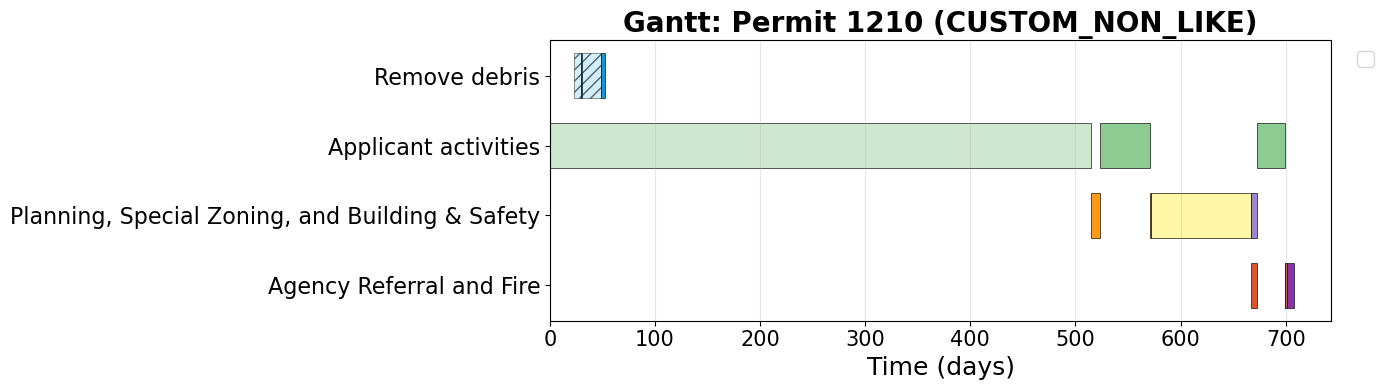

In [6]:
# Gantt chart for one random permit in segment 4 (CUSTOM_NON_LIKE)
# Parallel activities (e.g. Public Works, Fire Review, Public Health) appear on separate rows
from visualize_permits import plot_gantt_one_random_permit_segment
import matplotlib.pyplot as plt

fig, ax = plot_gantt_one_random_permit_segment(
    all_permits,
    segment_value=4,
    random_seed=100,
    figsize=(14, 4),
)
if fig:
    plt.show()

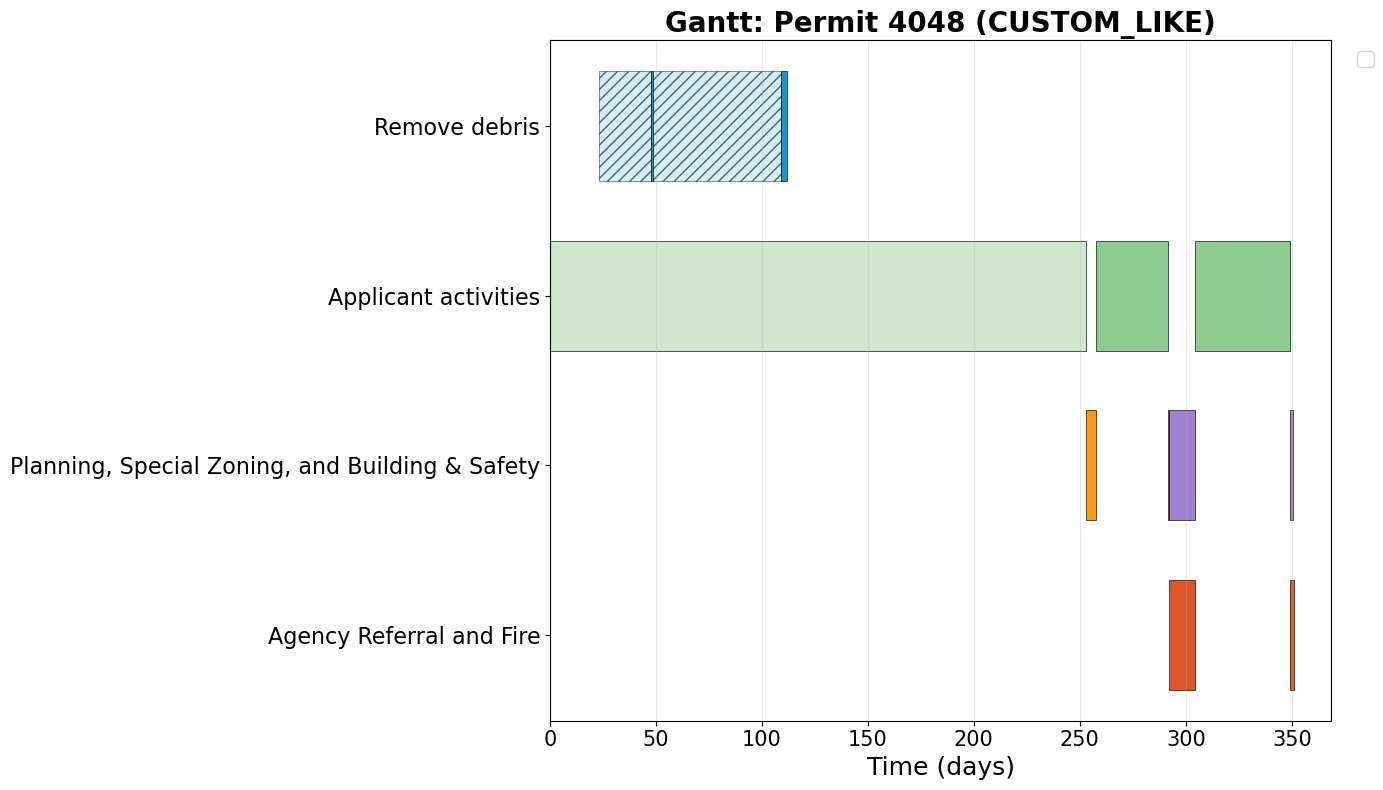

In [7]:
# Gantt chart for one random permit in segment 4 (CUSTOM_NON_LIKE)
# Parallel activities (e.g. Public Works, Fire Review, Public Health) appear on separate rows
from visualize_permits import plot_gantt_single_permit
import matplotlib.pyplot as plt
import random

# One random run from the 100, same list index as before (representative Gantt)
_run = random.Random(42).choice(results)
fig, ax = plot_gantt_single_permit(
    _run["permits"][1460],
    figsize=(14, 8), 
)
if fig:
    plt.show()

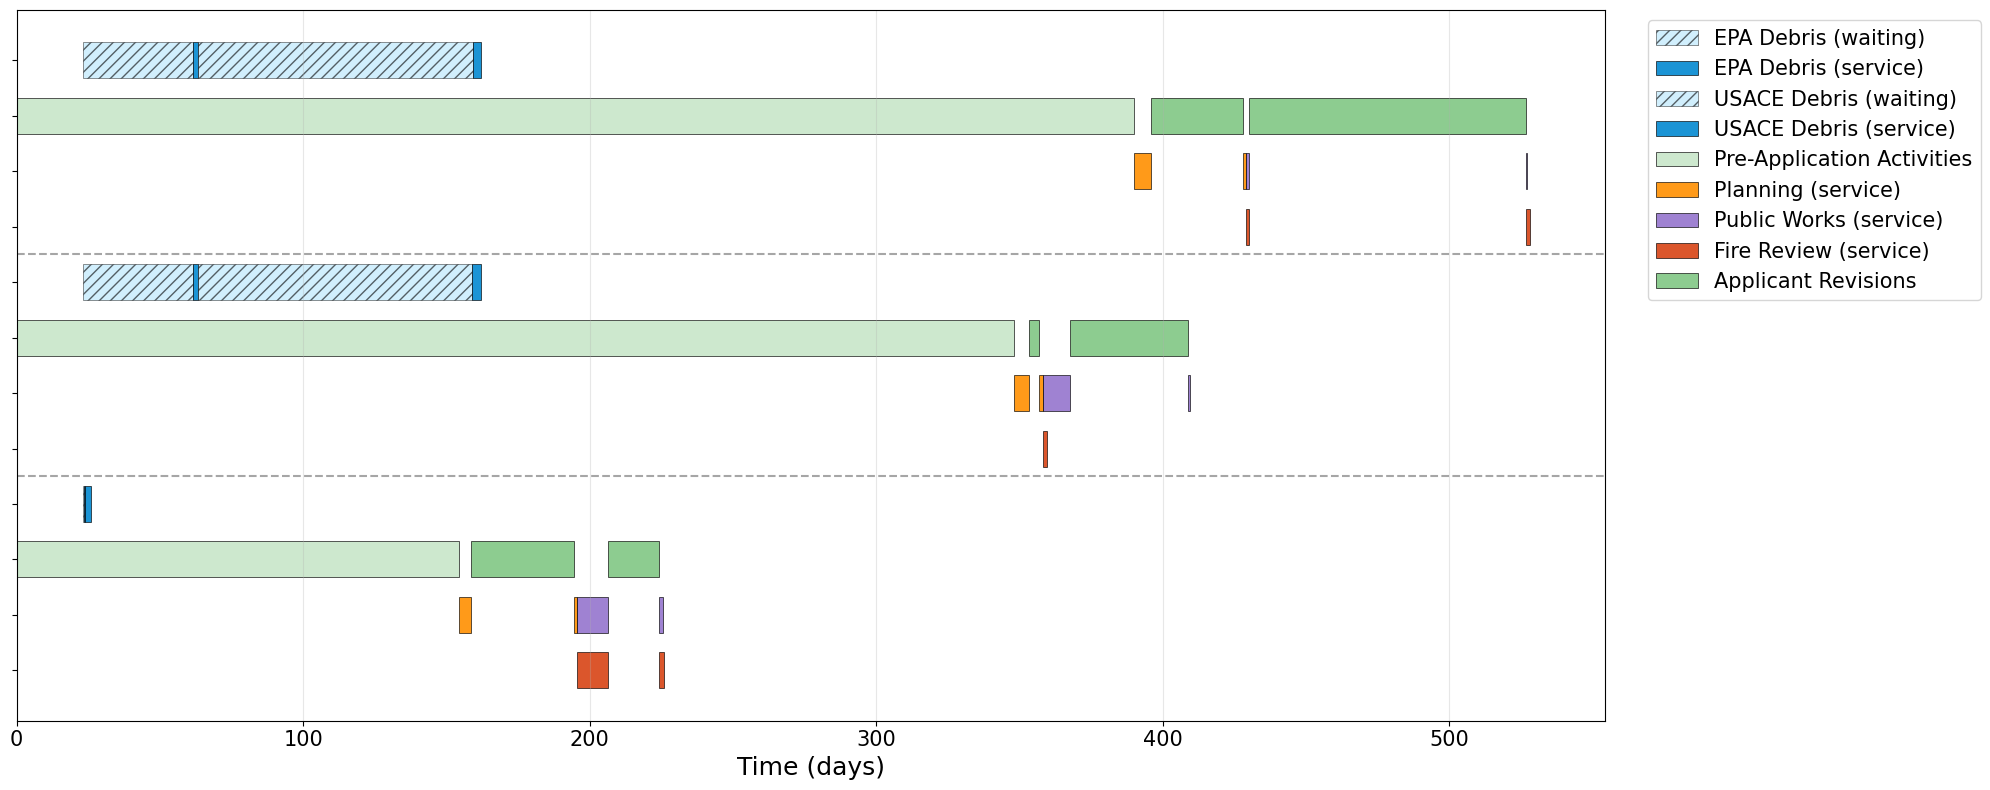

In [8]:
# Gantt chart for 3 random permits
from visualize_permits import plot_gantt_three_random_permits
import matplotlib.pyplot as plt

fig, ax = plot_gantt_three_random_permits(
    all_permits,
    random_seed=36,
    figsize=(20, 8),
)
if fig:
    plt.show()

Average waiting and service time by step (days):
  EPA Debris: waiting mean=19.49, σ=11.60; service mean=1.00, σ=0.49
  USACE Debris: waiting mean=48.04, σ=28.27; service mean=2.50, σ=0.50
  Pre-Application Activities: waiting mean=0.00, σ=0.00; service mean=631.62, σ=613.05
  Planning: waiting mean=0.00, σ=0.00; service mean=6.79, σ=1.84
  Special Zoning: waiting mean=0.00, σ=0.00; service mean=57.68, σ=45.67
  Public Works: waiting mean=0.00, σ=0.00; service mean=8.31, σ=2.90
  Agency Referral: waiting mean=0.00, σ=0.00; service mean=38.45, σ=30.33
  Fire Review: waiting mean=0.00, σ=0.07; service mean=4.68, σ=3.56
  Applicant Revisions: waiting mean=0.00, σ=0.00; service mean=95.55, σ=39.99


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Average Total Waiting vs Service Time by Process Step'}, xlabel='Process Step', ylabel='Average Time (days)'>)

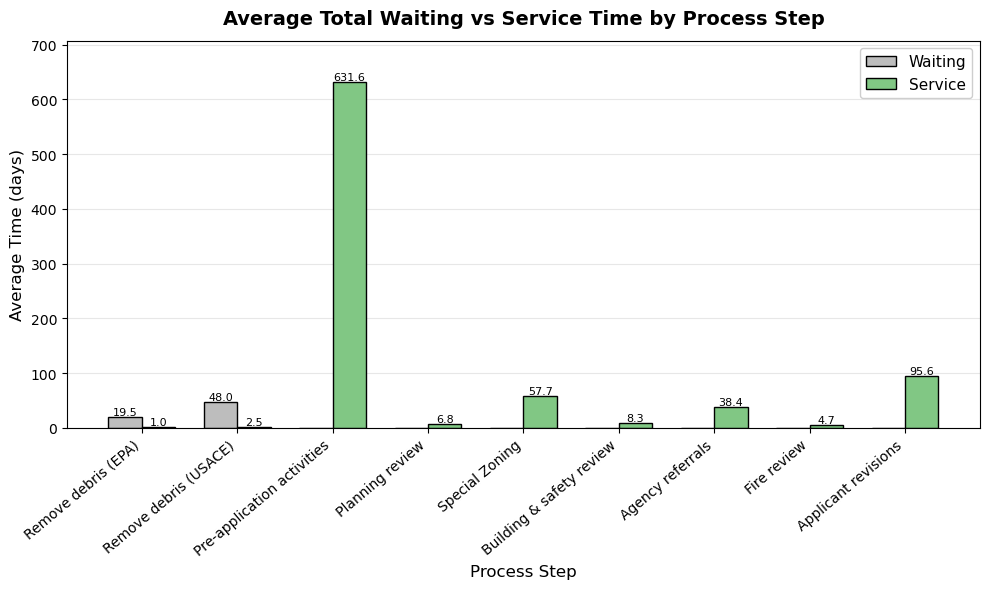

In [9]:
# Visualize the time each permit spends in each stage
from visualize_permits import plot_average_waiting_and_service_by_step


# Visualize aggregate time spent in each process stage across all runs
label_map = {
    "EPA Debris": "Remove debris (EPA)",
    "USACE Debris": "Remove debris (USACE)",
    "Pre-Application Activities": "Pre-application activities",
    "Planning": "Planning review",
    "Special Zoning Review": "Special zoning review",
    "Public Works": "Building & safety review",
    "Agency Referral": "Agency referrals",
    "Fire Review": "Fire review",
    "Applicant Revisions": "Applicant revisions",
}
plot_average_waiting_and_service_by_step(all_permits, label_map=label_map)


Calculate statistics to understand the amount of time between the end of debris removal and plan submission

In [10]:
import statistics

deltas = [
    p.plan_prep_end - p.debris_removal_end
    for p in all_permits
    if p.plan_prep_end is not None and p.debris_removal_end is not None
]

statistics.mean(deltas), statistics.median(deltas)

(np.float64(537.6000611119539), np.float64(344.0702379651269))

In [11]:
starts = [p.epa_debris_service_start for p in all_permits if p.epa_debris_service_start is not None]
ends = [p.epa_debris_end for p in all_permits if p.epa_debris_end is not None]
if starts and ends:
    span = max(ends) - min(starts)  # first start → last end
    print("First EPA start:", min(starts), "Last EPA end:", max(ends), "Span:", span)

First EPA start: 23 Last EPA end: 65.53650376123112 Span: 42.53650376123112


In [ ]:
# Day-415 step completion status update
import simpy
from permit_simulation import PermitSimulation

DAY = 415
NUM_PERMITS = 6410
RANDOM_SEED = 42
SEQUENTIAL_MODE = "standard"  # "standard", "parallel", or "sequential"
AI_REVIEW = "none"

env = simpy.Environment()
sim = PermitSimulation(env, random_seed=RANDOM_SEED, ai_review=AI_REVIEW)

for _ in range(NUM_PERMITS):
    permit = sim.create_permit()
    if SEQUENTIAL_MODE == "standard":
        env.process(sim.permit_process(permit))
    elif SEQUENTIAL_MODE == "parallel":
        env.process(sim.permit_process_parallel(permit))
    elif SEQUENTIAL_MODE == "sequential":
        env.process(sim.permit_process_sequential(permit))
    else:
        raise ValueError(f"Invalid SEQUENTIAL_MODE: {SEQUENTIAL_MODE}")

env.run(until=DAY)
permits = list(sim.completed_permits) + list(sim.in_progress_permits.values())

steps = [
    ("EPA debris complete", "epa_debris_end"),
    ("USACE debris complete", "usace_debris_end"),
    ("Debris removal complete", "debris_removal_end"),
    ("Plan preparation complete", "plan_prep_end"),
    ("Planning review approved", "planning_end"),
    ("Special zoning complete", "zoning_end"),
    ("Agency referral complete", "agency_referral_end"),
    ("Public Works approved", "public_works_end"),
    ("Fire review approved", "fire_review_end"),
    ("Ready for construction", "ready_for_construction"),
]

print(f"Time horizon: day {DAY}")
print(f"Total permits created: {NUM_PERMITS}")
print(f"Permits completed by day {DAY}: {len(sim.completed_permits)}")
print("---")
for label, attr in steps:
    count = sum(1 for p in permits if getattr(p, attr) is not None and getattr(p, attr) <= DAY)
    pct = 100.0 * count / NUM_PERMITS
    print(f"{label:30s} {count:5d} ({pct:6.2f}%)")